# Processed Data Verification
Sanity checks on preprocessed output before building the dataloader.

Checks:
1. All cases processed (no missing files)
2. Shapes and spacings are uniform
3. Mask values are strictly binary {0, 1}
4. FLAIR/T1 intensities look z-scored (mean ≈ 0, std ≈ 1 on brain voxels)
5. Visual overlay — FLAIR + WMH mask looks correct per site
6. Lesion load distribution across training set

In [1]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from collections import Counter

In [2]:
# Change to wherever you saved your processed data
PROCESSED_ROOT = Path('/data/users/ssethi2/mmml_repos/guided-brightspot/data/processed')

TARGET_SIZE    = (200, 200, 48)
TARGET_SPACING = (1.0, 1.0, 3.0)

def load_case(case_dir):
    flair = sitk.ReadImage(str(case_dir / 'FLAIR.nii'))
    t1    = sitk.ReadImage(str(case_dir / 'T1.nii'))
    wmh   = sitk.ReadImage(str(case_dir / 'wmh.nii'))
    return flair, t1, wmh

def get_all_cases(split):
    split_dir = PROCESSED_ROOT / split
    cases = []
    for case_dir in sorted(split_dir.rglob('FLAIR.nii')):
        patient_dir = case_dir.parent
        # Handle Amsterdam subdirs (e.g. Amsterdam/GE3T)
        rel = patient_dir.relative_to(split_dir)
        parts = rel.parts  # e.g. ('Utrecht', '0') or ('Amsterdam', 'GE3T', '100')
        site = '/'.join(parts[:-1])
        pid  = parts[-1]
        cases.append({
            'split': split,
            'site': site,
            'patient_id': pid,
            'dir': patient_dir,
        })
    return cases

train_cases = get_all_cases('training')
test_cases = get_all_cases('test')  

print(f'Training cases found: {len(train_cases)}')
for site, count in sorted(Counter(c['site'] for c in train_cases).items()):
    print(f'  {site}: {count}')

print(f'\nTest cases found: {len(test_cases)}')
for site, count in sorted(Counter(c['site'] for c in test_cases).items()):
    print(f'  {site}: {count}')

Training cases found: 60
  Amsterdam/GE3T: 20
  Singapore: 20
  Utrecht: 20

Test cases found: 110
  Amsterdam/GE1T5: 10
  Amsterdam/GE3T: 30
  Amsterdam/Philips_VU .PETMR_01.: 10
  Singapore: 30
  Utrecht: 30


## 1. Shape, spacing, and mask value check

In [3]:
def verify_cases(cases, label=''):
    issues = []
    shape_counts    = defaultdict(int)
    spacing_counts  = defaultdict(int)
    mask_val_counts = defaultdict(int)

    for case in cases:
        flair, _, wmh = load_case(case['dir'])
        wmh_arr = sitk.GetArrayFromImage(wmh)
        size    = flair.GetSize()
        spacing = tuple(round(s, 2) for s in flair.GetSpacing())
        unique  = tuple(np.unique(wmh_arr).tolist())

        shape_counts[size]      += 1
        spacing_counts[spacing] += 1
        mask_val_counts[unique] += 1

        shape_ok   = size == TARGET_SIZE
        spacing_ok = spacing == TARGET_SPACING
        mask_ok    = set(unique).issubset({0, 1})

        if not (shape_ok and spacing_ok and mask_ok):
            issues.append({
                'case': f"{case['site']}/{case['patient_id']}",
                'size': size, 'spacing': spacing, 'mask_vals': unique
            })

    if label:
        print(f'=== {label} ===')
    print(f'Cases checked:          {len(cases)}')
    print(f'Unique shapes:          {dict(shape_counts)}')
    print(f'Unique spacings:        {dict(spacing_counts)}')
    print(f'Unique mask val combos: {dict(mask_val_counts)}')

    if issues:
        print(f'\n⚠  {len(issues)} cases with issues:')
        for iss in issues:
            print(f"  {iss['case']}: shape={iss['size']}, spacing={iss['spacing']}, mask={iss['mask_vals']}")
    else:
        print(f'\nAll cases pass shape, spacing, and mask checks')

verify_cases(train_cases, label='TRAINING')
verify_cases(test_cases, label='TEST')

=== TRAINING ===
Cases checked:          60
Unique shapes:          {(200, 200, 48): 60}
Unique spacings:        {(1.0, 1.0, 3.0): 60}
Unique mask val combos: {(0, 1): 60}

All cases pass shape, spacing, and mask checks
=== TEST ===
Cases checked:          110
Unique shapes:          {(200, 200, 48): 110}
Unique spacings:        {(1.0, 1.0, 3.0): 110}
Unique mask val combos: {(0, 1): 110}

All cases pass shape, spacing, and mask checks


## 2. Intensity normalization check
Brain voxels should have mean ≈ 0, std ≈ 1 after z-score normalization

In [4]:
def check_normalization(cases):
    sample = sorted(cases, key=lambda x: (x['site'], x['patient_id']))
    print(f"{'Case':<35} {'FLAIR mean':>12} {'FLAIR std':>10} {'T1 mean':>10} {'T1 std':>10}")
    print('-' * 80)
    for case in sample:
        flair, t1, _ = load_case(case['dir'])
        fa = sitk.GetArrayFromImage(flair)
        ta = sitk.GetArrayFromImage(t1)
        fb = fa[fa != 0]
        tb = ta[ta != 0]
        label = f"{case['site']}/{case['patient_id']}"
        print(f"{label:<35} {fb.mean():>12.4f} {fb.std():>10.4f} {tb.mean():>10.4f} {tb.std():>10.4f}")
    print('\n(Values should be close to mean=0, std=1)')

In [5]:
check_normalization(train_cases)

Case                                  FLAIR mean  FLAIR std    T1 mean     T1 std
--------------------------------------------------------------------------------
Amsterdam/GE3T/100                       -0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE3T/101                       -0.0000     1.0000     0.0000     1.0000
Amsterdam/GE3T/102                        0.0000     1.0000     0.0000     1.0000
Amsterdam/GE3T/103                       -0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE3T/104                        0.0000     1.0000     0.0000     1.0000
Amsterdam/GE3T/105                       -0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE3T/106                        0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE3T/107                        0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE3T/108                       -0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE3T/109                        0.0000     1.0000     0.0000     1.0000
Amsterdam/GE3T/11

In [6]:
check_normalization(test_cases) 

Case                                  FLAIR mean  FLAIR std    T1 mean     T1 std
--------------------------------------------------------------------------------
Amsterdam/GE1T5/150                       0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE1T5/151                       0.0000     1.0000     0.0000     1.0000
Amsterdam/GE1T5/152                      -0.0000     1.0000     0.0000     1.0000
Amsterdam/GE1T5/153                      -0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE1T5/154                       0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE1T5/155                       0.0000     1.0000     0.0000     1.0000
Amsterdam/GE1T5/156                      -0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE1T5/157                      -0.0000     1.0000     0.0000     1.0000
Amsterdam/GE1T5/158                       0.0000     1.0000    -0.0000     1.0000
Amsterdam/GE1T5/159                       0.0000     1.0000     0.0000     1.0000
Amsterdam/GE3T/11

## 3. Visual check (one case per site)
Shows FLAIR, T1, WMH mask, and overlay at the slice with the most WMH voxels

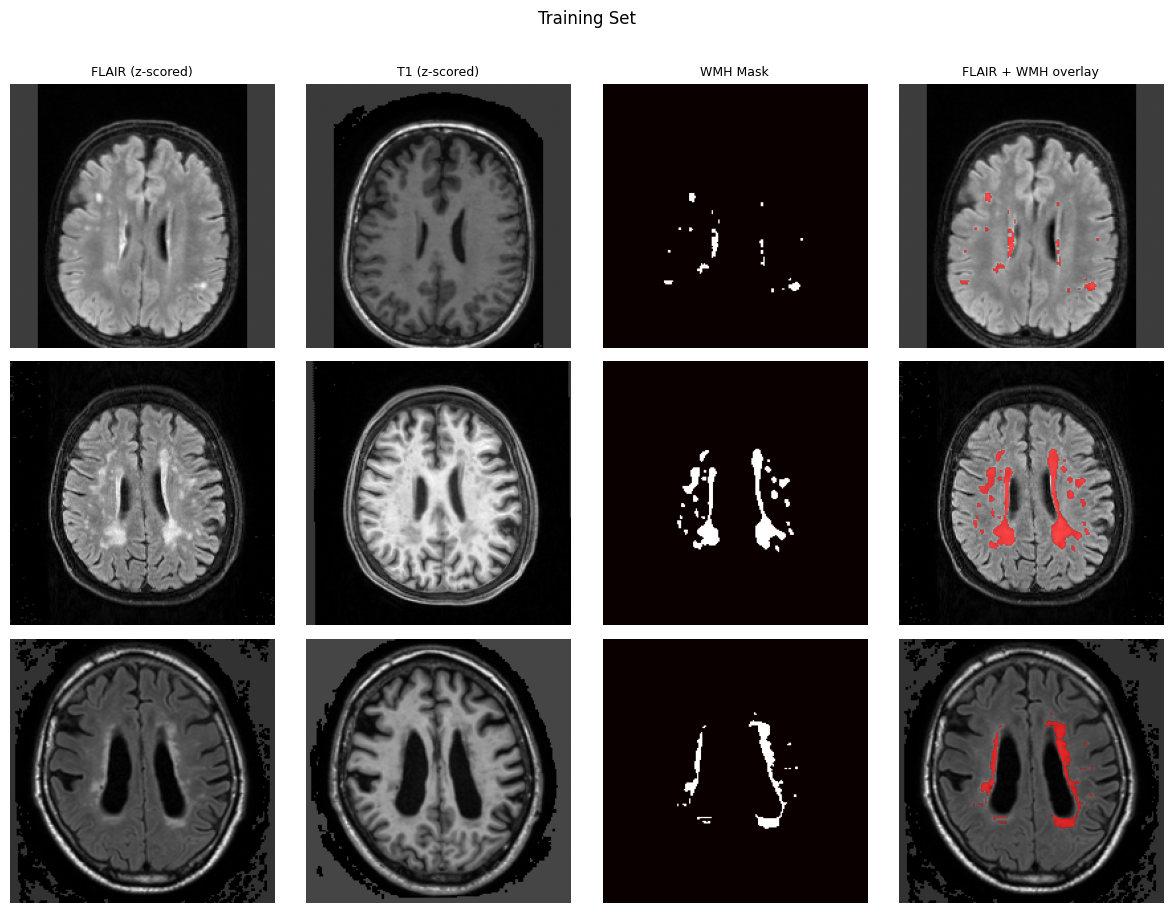

Saved to ../visualizations/verification_training_set.png


In [7]:
def normalize_for_display(arr):
    mn, mx = arr.min(), arr.max()
    return (arr.astype(float) - mn) / (mx - mn) if mx > mn else arr.astype(float)

def best_slice(wmh_arr):
    counts = wmh_arr.sum(axis=(1, 2))
    best = int(counts.argmax())
    return best if counts[best] > 0 else wmh_arr.shape[0] // 2

def visualize_site_examples(cases, title=''):
    site_examples = {}
    for case in sorted(cases, key=lambda x: (x['site'], x['patient_id'])):
        if case['site'] not in site_examples:
            site_examples[case['site']] = case

    sites = sorted(site_examples.keys())
    fig, axes = plt.subplots(len(sites), 4, figsize=(12, 3 * len(sites)))
    
    if len(sites) == 1:
        axes = [axes]

    col_labels = ['FLAIR (z-scored)', 'T1 (z-scored)', 'WMH Mask', 'FLAIR + WMH overlay']

    for row, site in enumerate(sites):
        case = site_examples[site]
        flair, t1, wmh = load_case(case['dir'])
        fa = sitk.GetArrayFromImage(flair)
        ta = sitk.GetArrayFromImage(t1)
        wa = sitk.GetArrayFromImage(wmh)

        sl    = best_slice(wa)
        f_sl  = fa[sl]
        t_sl  = ta[sl]
        w_sl  = wa[sl]

        ax = axes[row]
        ax[0].imshow(normalize_for_display(f_sl), cmap='gray')
        ax[0].set_ylabel(f"{site}\npid={case['patient_id']}\nslice={sl}", fontsize=9, rotation=0, labelpad=40, va='center')
        ax[1].imshow(normalize_for_display(t_sl), cmap='gray')
        ax[2].imshow(w_sl, cmap='hot', vmin=0, vmax=1)
        ax[3].imshow(normalize_for_display(f_sl), cmap='gray')
        ax[3].imshow(np.ma.masked_where(w_sl == 0, w_sl), cmap='autumn', alpha=0.7)

        for i, a in enumerate(ax):
            if row == 0:
                a.set_title(col_labels[i], fontsize=9)
            a.axis('off')

    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    fname = f'../visualizations/verification_{title.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {fname}')

visualize_site_examples(train_cases, title='Training Set')

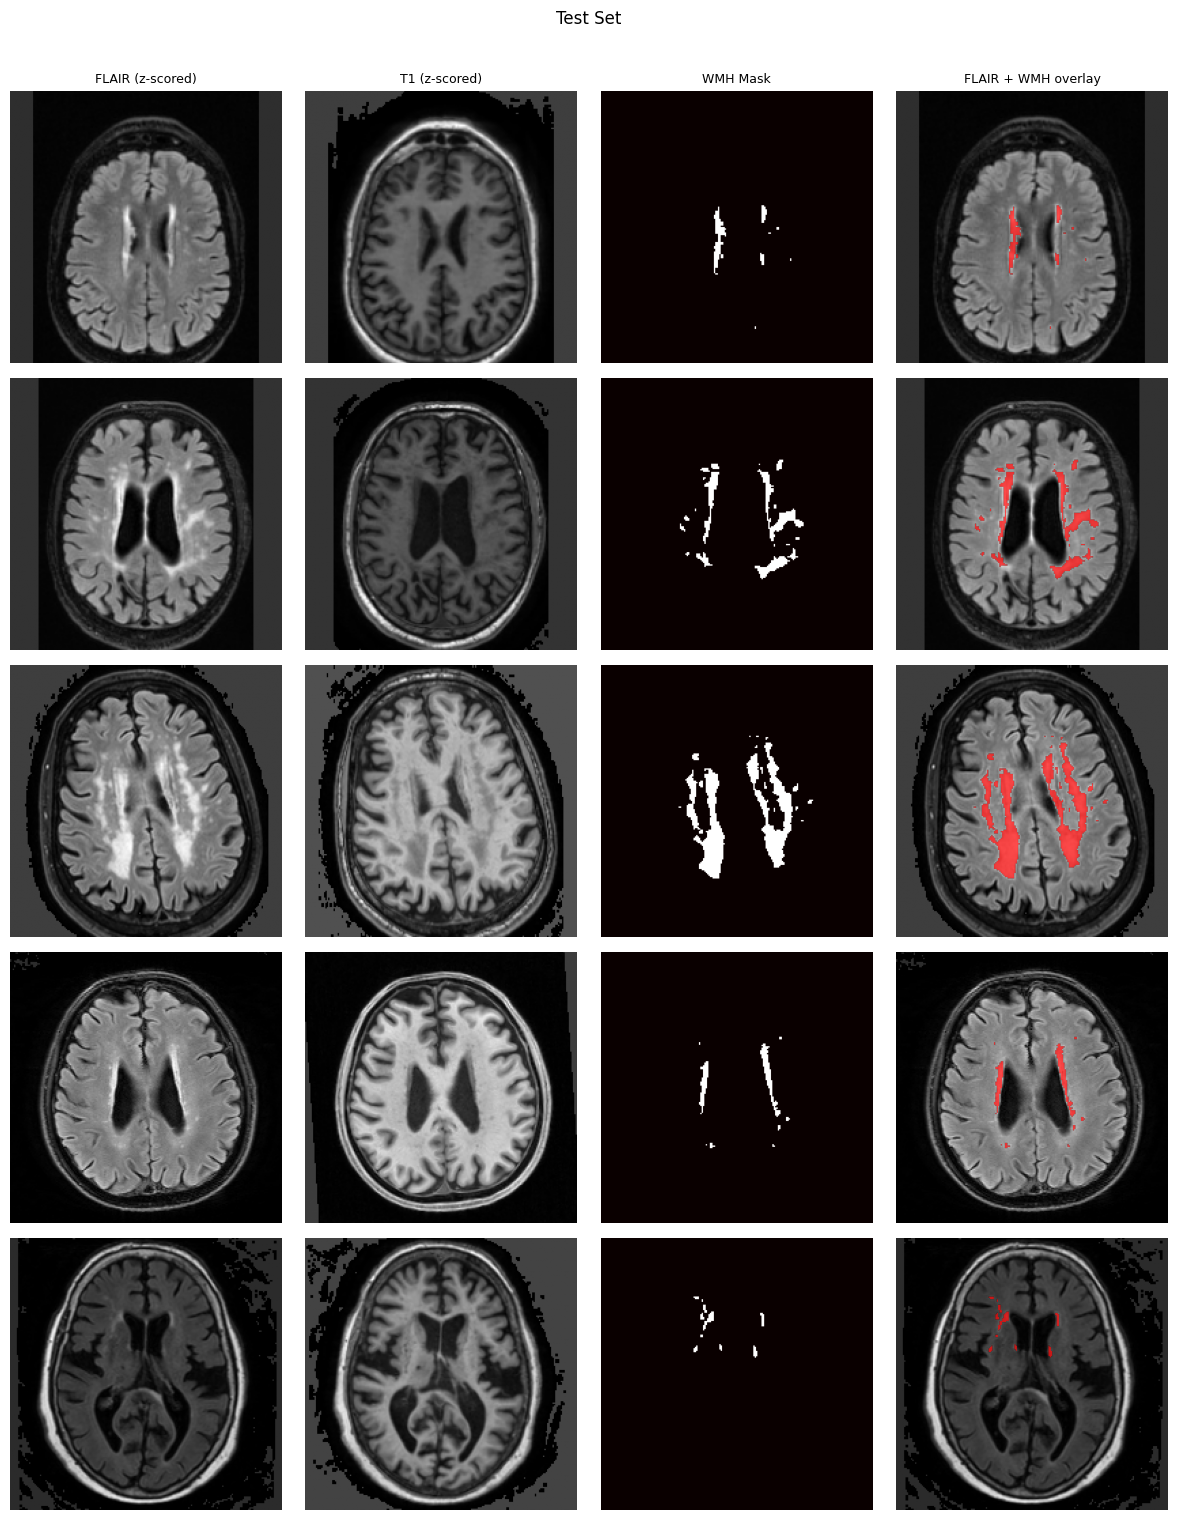

Saved to ../visualizations/verification_test_set.png


In [8]:
visualize_site_examples(test_cases, title='Test Set')

## 4. Lesion load distribution
Checks lesion sizes are reasonable and flags any cases with zero lesion voxels

Amsterdam/GE3T: min=511, max=14456, mean=3571, std=3660
Singapore: min=262, max=20444, mean=6371, std=4872
Utrecht: min=292, max=25122, mean=7765, std=7362


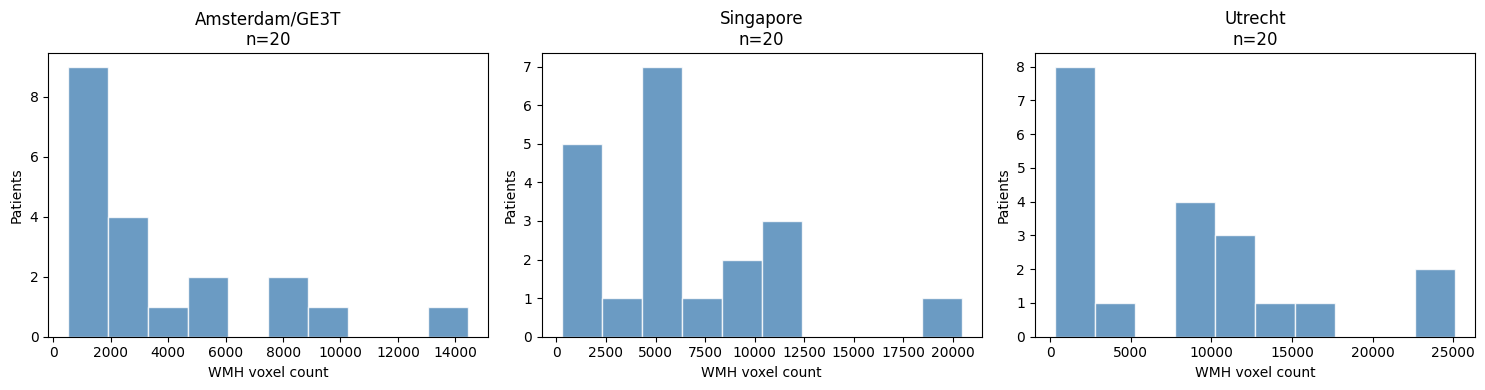


All cases have at least some lesion voxels


In [9]:
lesion_voxels_per_site = defaultdict(list)
zero_lesion_cases = []

for case in train_cases:
    _, _, wmh = load_case(case['dir'])
    wa = sitk.GetArrayFromImage(wmh)
    n  = int(wa.sum())
    lesion_voxels_per_site[case['site']].append(n)
    if n == 0:
        zero_lesion_cases.append(f"{case['site']}/{case['patient_id']}")

sites_sorted = sorted(lesion_voxels_per_site.keys())
fig, axes = plt.subplots(1, len(sites_sorted), figsize=(5 * len(sites_sorted), 4))
if len(sites_sorted) == 1:
    axes = [axes]

for idx, site in enumerate(sites_sorted):
    voxel_counts = lesion_voxels_per_site[site]
    axes[idx].hist(voxel_counts, bins=10, color='steelblue', alpha=0.8, edgecolor='white')
    axes[idx].set_title(f'{site}\nn={len(voxel_counts)}')
    axes[idx].set_xlabel('WMH voxel count')
    axes[idx].set_ylabel('Patients')
    print(f'{site}: min={min(voxel_counts)}, max={max(voxel_counts)}, '
          f'mean={np.mean(voxel_counts):.0f}, std={np.std(voxel_counts):.0f}')

plt.tight_layout()
plt.savefig('../visualizations/verification_lesion_load.png', dpi=150, bbox_inches='tight')
plt.show()

if zero_lesion_cases:
    print(f'\nWARNING: Cases with zero lesion voxels after preprocessing:')
    for c in zero_lesion_cases:
        print(f'  {c}  <-- check raw mask for this patient')
else:
    print('\nAll cases have at least some lesion voxels')